# Memory

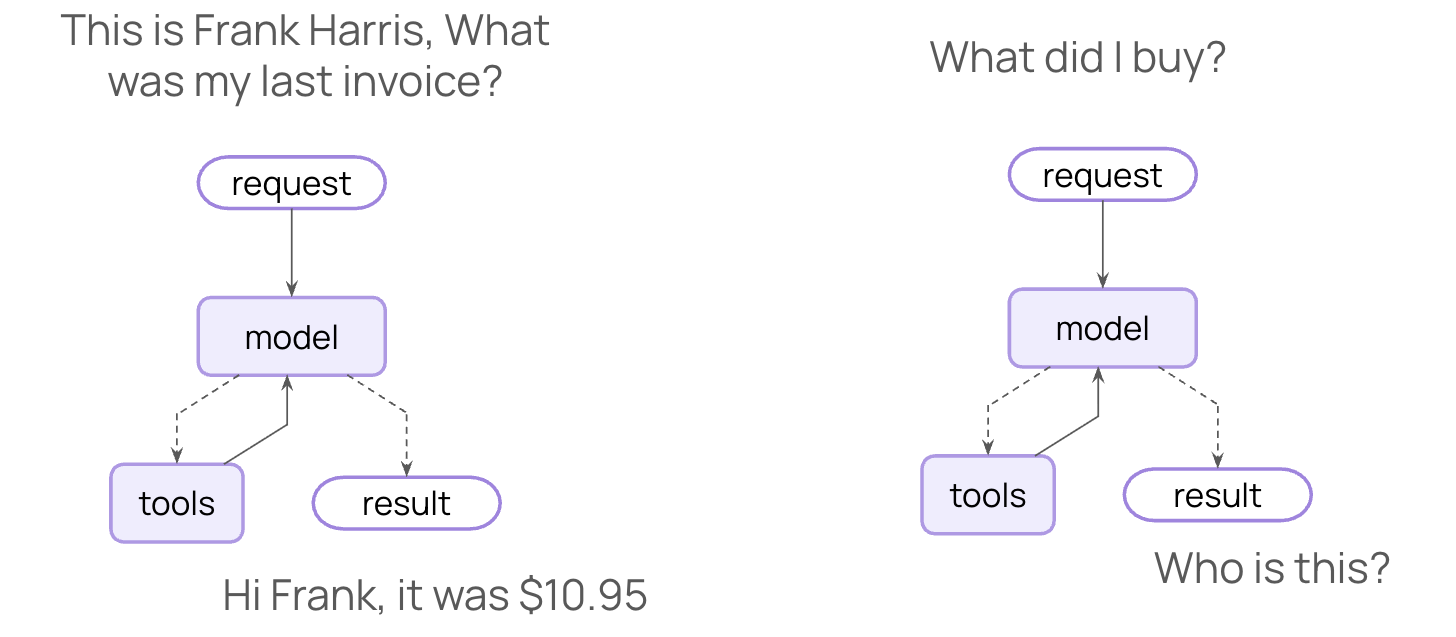

Persisting messages, or 'agent state' between invocations of the agent.

## Setup

Load and/or check for needed environmental variables

In [1]:
import os, httpx
from dotenv import load_dotenv

# Load .env using absolute path (override=True to ensure it always loads fresh)
load_dotenv("/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/.env", override=True)

CA_BUNDLE = "/Users/L107127/Library/CloudStorage/OneDrive-EliLillyandCompany/Desktop/Foundation-Introduction-to-LangGraph---Python/ca-bundle.pem"
os.environ["SSL_CERT_FILE"] = CA_BUNDLE
os.environ["REQUESTS_CA_BUNDLE"] = CA_BUNDLE

# Create a custom httpx client with the CA bundle
http_client = httpx.Client(verify=CA_BUNDLE)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [27]:
from langchain_groq import ChatGroq
llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct", temperature=0, http_client=http_client)

In [3]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///Chinook.db")

In [4]:
from dataclasses import dataclass

@dataclass
class RuntimeContext:
    db: SQLDatabase

In [5]:
from langchain_core.tools import tool
from langgraph.runtime import get_runtime

@tool
def execute_sql(query: str) -> str:
    """Execute a SQLite command and return results."""
    runtime = get_runtime(RuntimeContext)
    db = runtime.context.db

    try:
        return db.run(query)
    except Exception as e:
        return f"Error: {e}"

In [6]:
SYSTEM_PROMPT = """You are a careful SQLite analyst.

Rules:
- Think step-by-step.
- When you need data, call the tool `execute_sql` with ONE SELECT query.
- Read-only only; no INSERT/UPDATE/DELETE/ALTER/DROP/CREATE/REPLACE/TRUNCATE.
- Limit to 5 rows unless the user explicitly asks otherwise.
- If the tool returns 'Error:', revise the SQL and try again.
- Prefer explicit column lists; avoid SELECT *.
"""

In [7]:
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
)

## Repeated Queries

In [9]:
question = "This is Frank Harris, What was the total on my last invoice?"
steps = []

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
    context=RuntimeContext(db=db),
):
    step["messages"][-1].pretty_print()
    steps.append(step)

================================ Human Message =================================

This is Frank Harris, What was the total on my last invoice?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (f52dsnp8v)
 Call ID: f52dsnp8v
  Args:
    query: SELECT SUM(total) FROM invoices WHERE customer_name = 'Frank Harris'
================================= Tool Message =================================
Name: execute_sql

Error: (sqlite3.OperationalError) no such table: invoices
[SQL: SELECT SUM(total) FROM invoices WHERE customer_name = 'Frank Harris']
(Background on this error at: https://sqlalche.me/e/20/e3q8)
================================== Ai Message ==================================
Tool Calls:
  execute_sql (hgjq11101)
 Call ID: hgjq11101
  Args:
    query: PRAGMA table_info(invoices)
================================= Tool Message =================================
Name: execute_sql


================================== Ai Message ==

In [10]:
question = "What were the titles?"

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What were the titles?
================================== Ai Message ==================================
Tool Calls:
  execute_sql (vdyyfqnbx)
 Call ID: vdyyfqnbx
  Args:
    query: SELECT name FROM sqlite_master WHERE type='table'
================================= Tool Message =================================
Name: execute_sql

[('Album',), ('Artist',), ('Customer',), ('Employee',), ('Genre',), ('Invoice',), ('InvoiceLine',), ('MediaType',), ('Playlist',), ('PlaylistTrack',), ('Track',)]
================================== Ai Message ==================================
Tool Calls:
  execute_sql (he9nwbf78)
 Call ID: he9nwbf78
  Args:
    query: SELECT name FROM sqlite_master WHERE type='view'
================================= Tool Message =================================
Name: execute_sql


================================== Ai Message ==================================
Tool Calls:
  execute_sql (n6bgk7ax2

## Add memory

In [11]:
from langgraph.checkpoint.memory import InMemorySaver

In [28]:
from langchain.agents import create_agent
from langchain_core.messages import SystemMessage

agent = create_agent(
    model=llm,
    tools=[execute_sql],
    system_prompt=SYSTEM_PROMPT,
    context_schema=RuntimeContext,
    checkpointer=InMemorySaver(),
)

In [29]:
question = "This is Frank Harris, What was the total on my last invoice?"
steps = []

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    {"configurable": {"thread_id": "1"}},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()
    steps.append(step)

================================ Human Message =================================

This is Frank Harris, What was the total on my last invoice?
================================== Ai Message ==================================

I don't have access to specific information about your invoices or account details. However, I can guide you on how you might be able to find this information. You may want to check your email for the last invoice you received or log in to your account on the platform where you made the transactions to view your invoice history. If you need help with a query related to your invoices, I can assist with that. 

For example, if you had a database query to check invoice details, it might look something like this:
Tool Calls:
  execute_sql (egks99rdp)
 Call ID: egks99rdp
  Args:
    query: SELECT total FROM invoices WHERE customer_name = 'Frank Harris' ORDER BY invoice_date DESC LIMIT 1
================================= Tool Message =================================
Nam

In [31]:
question = "What were the titles?"
steps = []

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    {"configurable": {"thread_id": "1"}},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()
    steps.append(step)

================================ Human Message =================================

What were the titles?
================================== Ai Message ==================================

I don't have access to titles information.


## Try your own queries
Now that there is memory, check the agents recall!

In [ ]:
question = "Your Question Here?"
steps = []

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    {"configurable": {"thread_id": "1"}},
    context=RuntimeContext(db=db),
    stream_mode="values",
):
    step["messages"][-1].pretty_print()
    steps.append(step)